DATA ACQUISITION & CLEANING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
try:
    from google.colab import files
    files.upload()
except:
    print("Running in VS Code - upload skipped")

Running in VS Code - upload skipped


In [ ]:
df = pd.read_csv('hotel_bookings.csv', index_col =[0])
df

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
hotel,,,,,,,,,,,,,,,,,,,,,
Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
City Hotel,0,23,2017,August,35,30,2,5,2,0.0,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
City Hotel,0,102,2017,August,35,31,2,5,3,0.0,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
City Hotel,0,34,2017,August,35,31,2,5,2,0.0,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07


In [ ]:
df.shape

(119390, 31)

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Handling Missing Values

In [ ]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['children'] = df['children'].fillna(0)

In [ ]:
df.isna().sum()

is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

DATA CLEANING: Treating Outliers

In [ ]:
df = df[df['adr'] >= 0]

In [ ]:
df = df[df['adr'] < 1000]

In [ ]:
print(df.shape)

(119388, 31)


FEATURE ENGINEERING

In [ ]:
# Calculate total duration of stay
df['total_duration_of_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [ ]:
# Create a 'total_guests' column to understand party size
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [ ]:
# Drop rows where there are 0 total guests but a booking exists
df = df[df['total_guests'] > 0]

month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_numeric'] = df['arrival_date_month'].map(month_map)

print(f"Feature engineering complete. Final dataset shape for Week 1: {df.shape}")

Feature engineering complete. Final dataset shape for Week 1: (119208, 34)


EXPORT CLEANED DATA

In [ ]:
df.to_csv('cleaned_hotel_bookings.csv', index=False)
print("Data cleaning complete. File successfully saved as 'cleaned_hotel_bookings.csv'.")

Data cleaning complete. File successfully saved as 'cleaned_hotel_bookings.csv'.


EXPLORATORY DATA ANALYSIS (EDA)

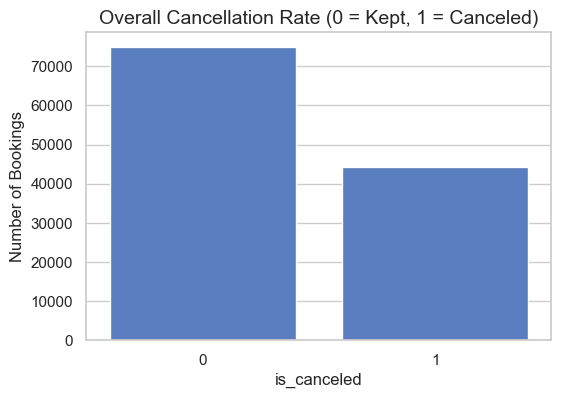

In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

# 1. The Churn Metric
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_canceled', data=df)
plt.title('Overall Cancellation Rate (0 = Kept, 1 = Canceled)', fontsize=14)
plt.ylabel('Number of Bookings')
plt.show()

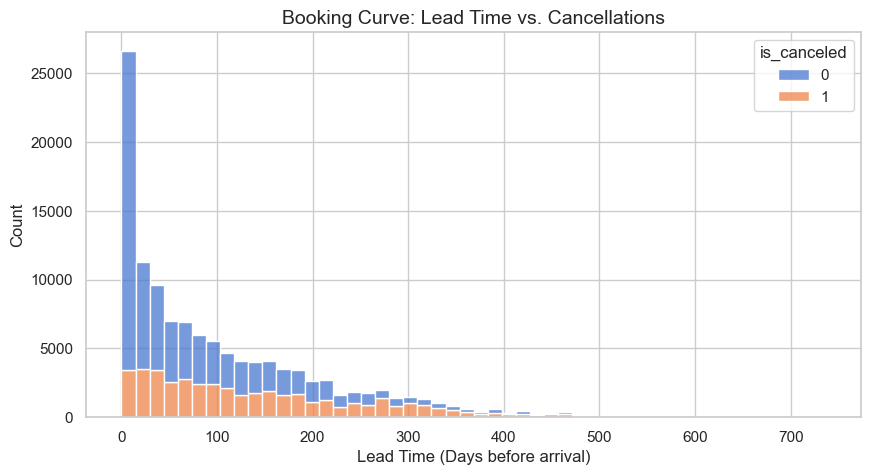

In [ ]:
# 2. The Booking Curve
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='lead_time', hue='is_canceled', multiple="stack", bins=50)
plt.title('Booking Curve: Lead Time vs. Cancellations', fontsize=14)
plt.xlabel('Lead Time (Days before arrival)')
plt.show()

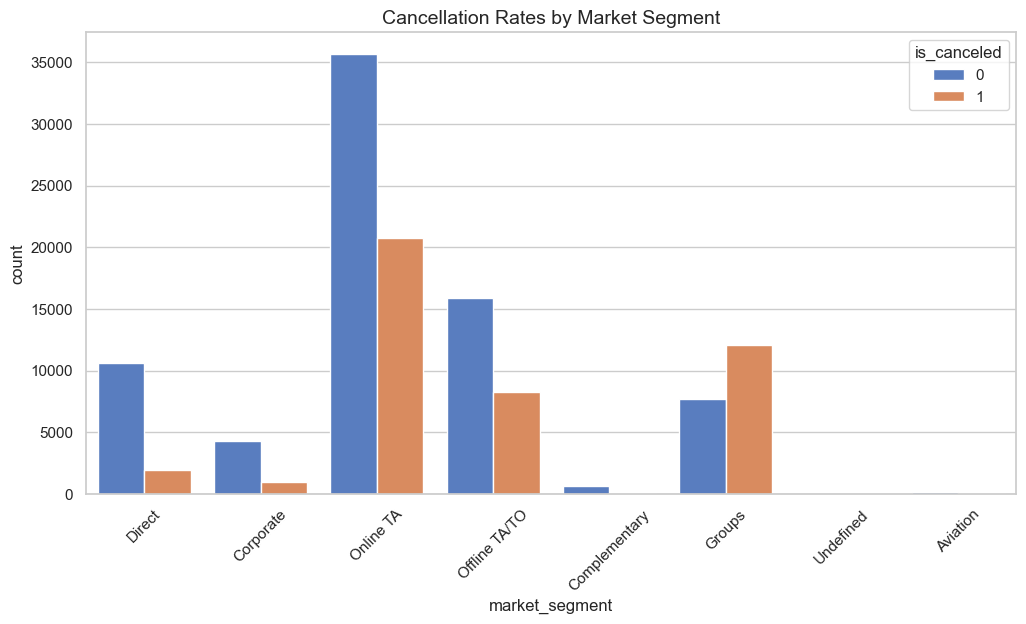

In [ ]:
# 3. Customer Segmentation
plt.figure(figsize=(12, 6))
sns.countplot(x='market_segment', hue='is_canceled', data=df)
plt.title('Cancellation Rates by Market Segment', fontsize=14)
plt.xticks(rotation=45)
plt.show()

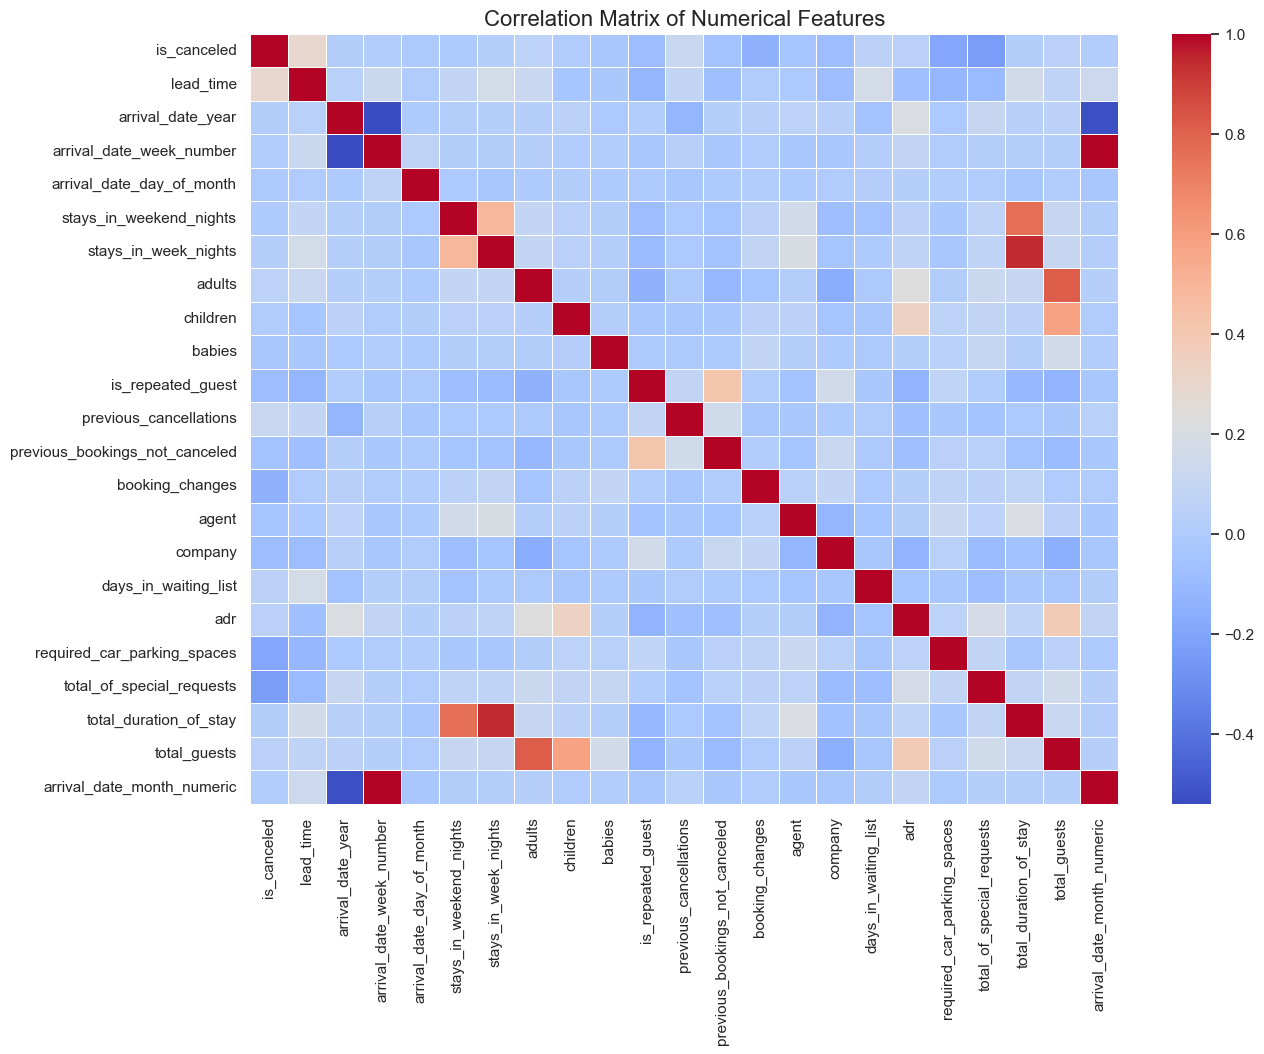

In [ ]:
# 4. Correlation Matrix
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

BASELINE PREDICTIVE MODELING


In [ ]:
# Select features to prevent data leakage
features = ['lead_time', 'total_guests', 'total_duration_of_stay', 'adr',
            'previous_cancellations', 'booking_changes', 'days_in_waiting_list']

categorical_features = ['market_segment', 'deposit_type', 'customer_type']
df_model = pd.get_dummies(df[features + categorical_features], drop_first=True)

In [ ]:
df_model

,lead_time,total_guests,total_duration_of_stay,adr,previous_cancellations,booking_changes,days_in_waiting_list,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
hotel,,,,,,,,,,,,,,,,,,,
Resort Hotel,342,2.0,0,0.00,0,3,0,False,False,True,False,False,False,False,False,False,False,True,False
Resort Hotel,737,2.0,0,0.00,0,4,0,False,False,True,False,False,False,False,False,False,False,True,False
Resort Hotel,7,1.0,1,75.00,0,0,0,False,False,True,False,False,False,False,False,False,False,True,False
Resort Hotel,13,1.0,1,75.00,0,0,0,False,True,False,False,False,False,False,False,False,False,True,False
Resort Hotel,14,2.0,2,98.00,0,0,0,False,False,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
City Hotel,23,2.0,7,96.14,0,0,0,False,False,False,False,True,False,False,False,False,False,True,False
City Hotel,102,3.0,7,225.43,0,0,0,False,False,False,False,False,True,False,False,False,False,True,False
City Hotel,34,2.0,7,157.71,0,0,0,False,False,False,False,False,True,False,False,False,False,True,False


In [ ]:
X = df_model
y = df['is_canceled']

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Evaluate Model
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("--- Model Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Model Performance Metrics ---
Accuracy:  0.7697
Precision: 0.8813
Recall:    0.4453
ROC-AUC:   0.8107


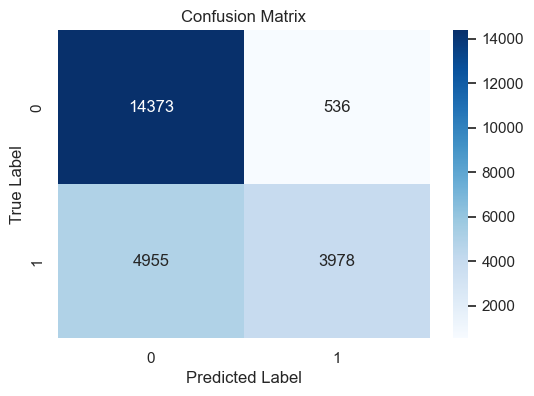

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

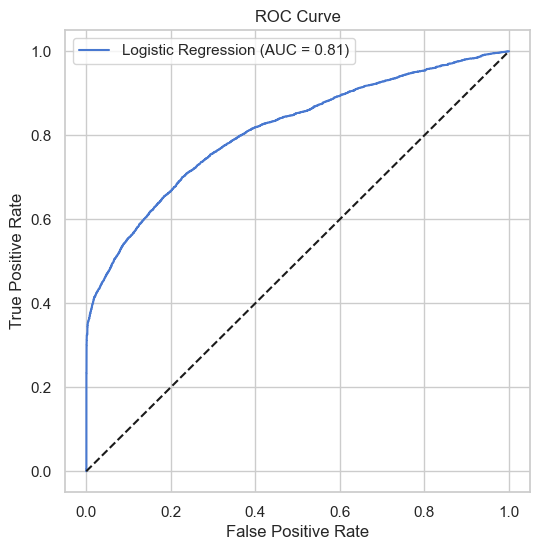

In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

DASHBOARD EXPORTS

In [ ]:
# Export 1: Seasonal Pricing Trends
seasonal_pricing = df.groupby(['arrival_date_month_numeric', 'arrival_date_year'])['adr'].mean().reset_index()
seasonal_pricing.to_csv('bi_seasonal_pricing.csv', index=False)

# Export 2: Customer Churn Demographics
segment_churn = df.groupby('market_segment')['is_canceled'].mean().reset_index()
segment_churn.rename(columns={'is_canceled': 'cancellation_rate'}, inplace=True)
segment_churn.to_csv('bi_segment_churn.csv', index=False)